# Dynamic Analysis — Toggle Power & Temporal Metrics

Measure actual switching activity from simulation VCD files to estimate dynamic power,
and extract temporal metrics (active/idle cycles, convergence speed, inference latency).

**Metrics:**
- **Dynamic Power**: Per-signal bit-level toggle counts (proxy for switching energy)
- **Active vs Idle Cycles**: Training cycles with actual STDP activity vs idle
- **Convergence Speed**: When do weights stop changing during training?
- **Inference Latency**: Which cycle does the output neuron first fire during test?

In [13]:
import subprocess
import re
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

# Paths
PROJECT_ROOT = os.path.abspath("..")
PPA_ROOT = os.path.dirname(os.path.abspath("__file__"))  # ppa/

# Load architecture definitions from ground truth
with open(os.path.join(PPA_ROOT, "architectures.json")) as f:
    ARCH_CONFIG = json.load(f)

# Map each arch to its make command and VCD file
DESIGNS = {}
for key, arch in ARCH_CONFIG["architectures"].items():
    is_optimized = "optimized" in arch["rtl_file"]
    make_target = "ablation-optimized" if is_optimized else "ablation"
    vcd_file = "dynamic_optimized_snn.vcd" if is_optimized else "dynamic_snn.vcd"
    DESIGNS[key] = {
        "label": arch["label"],
        "group": arch["group"],
        "make_target": make_target,
        "sim_parameters": arch["sim_parameters"],
        "synth_parameters": arch["synth_parameters"],
        "vcd_file": vcd_file,
    }

BASELINE_KEY = "triplet"

print(f"Project root: {PROJECT_ROOT}")
print(f"Designs ({len(DESIGNS)}):")
for key, d in DESIGNS.items():
    params = " ".join(f"{k}={v}" for k, v in d["sim_parameters"].items()) if d["sim_parameters"] else "(defaults)"
    print(f"  [{d['group']}] {d['label']}: make {d['make_target']} {params} -> {d['vcd_file']}")
print(f"Baseline: {BASELINE_KEY}")

Project root: /Users/dakotabarnes/Develop/274/triplet-snn
Designs (8):
  [baseline] Original Pair: make ablation W_BITS=2 TRACE_BITS=2 TRIPLET_EN=0 LEAK_EN=0 -> dynamic_snn.vcd
  [baseline] Pair: make ablation TRIPLET_EN=0 -> dynamic_snn.vcd
  [baseline] Triplet: make ablation (defaults) -> dynamic_snn.vcd
  [optimized] Triplet Optimized: make ablation-optimized (defaults) -> dynamic_optimized_snn.vcd
  [optimized] Triplet Opt. Spike-Gated: make ablation-optimized SPIKE_GATE_EN=1 -> dynamic_optimized_snn.vcd
  [optimized] Triplet Opt. Nearest-Neighbor: make ablation-optimized MODE=1 -> dynamic_optimized_snn.vcd
  [optimized] Triplet Opt. Seg. Adder: make ablation-optimized SEG_ADDER_EN=1 -> dynamic_optimized_snn.vcd
  [optimized] Triplet Opt. LUT-STDP: make ablation-optimized SPIKE_GATE_EN=1 LUT_STDP_EN=1 -> dynamic_optimized_snn.vcd
Baseline: triplet


## VCD Parser

Lightweight parser for iverilog-generated VCD (IEEE 1364).
Counts bit-level toggles per signal and tracks per-timestep activity.

In [14]:
def parse_vcd(vcd_path):
    """Parse a VCD file. Returns toggle counts, per-timestep activity, and metadata.

    Returns:
        toggles: dict {signal_name: bit_flip_count}
        timeline: list of (timestamp, set_of_signals_that_changed)
        var_info: dict {var_id: (name, width, var_type)}
    """
    var_info = {}     # var_id -> (name, width, var_type)
    prev_vals = {}    # var_id -> binary string
    toggles = defaultdict(int)   # signal_name -> total bit flips
    timeline = []     # (timestamp, {signal_names that changed})

    current_time = 0
    current_changes = set()
    in_header = True
    scope_stack = []

    with open(vcd_path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # --- Header section ---
            if in_header:
                if line.startswith("$scope"):
                    parts = line.split()
                    if len(parts) >= 3:
                        scope_stack.append(parts[2])
                elif line.startswith("$upscope"):
                    if scope_stack:
                        scope_stack.pop()
                elif line.startswith("$var"):
                    # $var <type> <width> <id> <name> [<range>] $end
                    parts = line.split()
                    var_type = parts[1]  # wire, reg, parameter, integer
                    width = int(parts[2])
                    var_id = parts[3]
                    raw_name = parts[4]
                    # Clean up escaped names: \w1[0] -> w1[0]
                    name = raw_name.lstrip("\\")
                    var_info[var_id] = (name, width, var_type)
                elif line.startswith("$enddefinitions"):
                    in_header = False
                continue

            # --- Data section ---
            # Skip $dumpall, $dumpvars, $end, $comment sections
            if line.startswith("$"):
                continue

            # Timestamp
            if line.startswith("#"):
                # Save previous timestep's changes
                if current_changes:
                    timeline.append((current_time, current_changes))
                    current_changes = set()
                current_time = int(line[1:])
                continue

            # Value change: multi-bit "b<val> <id>" or single-bit "<val><id>"
            if line.startswith("b") or line.startswith("B"):
                # Multi-bit: b0101 <id>
                parts = line.split()
                if len(parts) < 2:
                    continue
                new_val = parts[0][1:]  # strip 'b'
                var_id = parts[1]
            elif line[0] in "01xXzZ":
                # Single-bit: 0<id> or 1<id>
                new_val = line[0]
                var_id = line[1:]
            else:
                continue

            if var_id not in var_info:
                continue

            name, width, var_type = var_info[var_id]

            # Skip parameters and integers (constants, loop counters)
            if var_type in ("parameter", "integer"):
                continue

            # Pad new_val to width and normalize x/z to 0
            clean_val = new_val.replace("x", "0").replace("X", "0").replace("z", "0").replace("Z", "0")
            clean_val = clean_val.zfill(width)

            # Count bit-level flips vs previous value
            old_val = prev_vals.get(var_id)
            if old_val is not None:
                flips = sum(1 for a, b in zip(old_val, clean_val) if a != b)
                if flips > 0:
                    toggles[name] += flips
                    current_changes.add(name)

            prev_vals[var_id] = clean_val

    # Save final timestep
    if current_changes:
        timeline.append((current_time, current_changes))

    return dict(toggles), timeline, var_info


print("VCD parser ready.")

VCD parser ready.


## Signal Categorization

Group signals for breakdown analysis.

In [15]:
CATEGORIES = {
    "weights":   lambda n: n.startswith(("w1[", "w2[")),
    "traces":    lambda n: n.startswith(("r1[", "r2[", "o1_", "o2_")),
    "membrane":  lambda n: n in ("V1", "V2") or n.startswith(("wsum1", "wsum2")),
    "control":   lambda n: n.startswith(("spike", "need_reset", "any_spike")) or n in ("train", "rst"),
    "input":     lambda n: n.startswith(("S_in",)),
}


def categorize_signal(name):
    """Return the category for a signal name."""
    for cat, match_fn in CATEGORIES.items():
        if match_fn(name):
            return cat
    return "other"


def aggregate_by_category(toggles):
    """Sum toggle counts by signal category."""
    cats = defaultdict(int)
    for name, count in toggles.items():
        cats[categorize_signal(name)] += count
    return dict(cats)


# Category display order and colors
CAT_ORDER = ["weights", "traces", "membrane", "control", "input", "other"]
CAT_COLORS = {"weights": "#4C72B0", "traces": "#55A868", "membrane": "#C44E52",
              "control": "#8172B2", "input": "#CCB974", "other": "#999999"}

print("Signal categories defined.")

Signal categories defined.


## Run Simulations & Collect VCD Data

Run each architecture sequentially (VCD filename collisions) and parse immediately.

In [16]:
def run_simulation(design):
    """Run make ablation for a design and return stdout."""
    args = " ".join(f"{k}={v}" for k, v in design["sim_parameters"].items())
    cmd = f"make {design['make_target']} {args}".strip()
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True, cwd=PROJECT_ROOT)
    if result.returncode != 0:
        print(f"    ERROR (exit {result.returncode}): {result.stderr[:200]}")
    return result.stdout


# Collect data for all architectures
results = {}  # key -> {toggles, timeline, categories, stdout}

for key, design in DESIGNS.items():
    print(f"  Running: {design['label']} ...", end=" ", flush=True)

    # Run simulation
    stdout = run_simulation(design)

    # Parse VCD immediately (before next run overwrites it)
    vcd_path = os.path.join(PROJECT_ROOT, design["vcd_file"])
    if not os.path.exists(vcd_path):
        print(f"MISSING VCD: {vcd_path}")
        continue

    toggles, timeline, var_info = parse_vcd(vcd_path)
    categories = aggregate_by_category(toggles)

    results[key] = {
        "toggles": toggles,
        "timeline": timeline,
        "var_info": var_info,
        "categories": categories,
        "stdout": stdout,
    }

    total = sum(toggles.values())
    print(f"OK ({total:,} bit-toggles, {len(timeline)} timesteps)")

print(f"\nCollected data for {len(results)} architectures.")

  Running: Original Pair ... OK (8,497 bit-toggles, 415 timesteps)
  Running: Pair ... OK (13,885 bit-toggles, 415 timesteps)
  Running: Triplet ... OK (13,445 bit-toggles, 415 timesteps)
  Running: Triplet Optimized ... OK (13,666 bit-toggles, 415 timesteps)
  Running: Triplet Opt. Spike-Gated ... OK (13,666 bit-toggles, 415 timesteps)
  Running: Triplet Opt. Nearest-Neighbor ... OK (13,566 bit-toggles, 415 timesteps)
  Running: Triplet Opt. Seg. Adder ... OK (14,081 bit-toggles, 415 timesteps)
  Running: Triplet Opt. LUT-STDP ... OK (13,652 bit-toggles, 415 timesteps)

Collected data for 8 architectures.


## Dynamic Power Analysis

Compare total and per-category toggle counts across architectures.
Toggle count is proportional to dynamic power (same process, same V²·C).

In [17]:
# Build power DataFrame
power_rows = []
baseline_total = sum(results[BASELINE_KEY]["toggles"].values()) if BASELINE_KEY in results else 1

for key, design in DESIGNS.items():
    if key not in results:
        continue
    cats = results[key]["categories"]
    total = sum(results[key]["toggles"].values())
    n_timesteps = len(results[key]["timeline"])

    row = {
        "Design": design["label"],
        "Group": design["group"],
        "Total Toggles": total,
        "Toggles/Timestep": round(total / max(n_timesteps, 1), 1),
    }
    for cat in CAT_ORDER:
        row[f"{cat.title()} Toggles"] = cats.get(cat, 0)

    # Delta vs baseline
    if key != BASELINE_KEY:
        delta_pct = (total - baseline_total) / baseline_total * 100
        row["\u0394 vs Triplet"] = f"{delta_pct:+.1f}%"
    else:
        row["\u0394 vs Triplet"] = "baseline"

    power_rows.append(row)

df_power = pd.DataFrame(power_rows)
print("Dynamic Power — Toggle Count Comparison:")
display(df_power)

Dynamic Power — Toggle Count Comparison:


,Design,Group,Total Toggles,Toggles/Timestep,Weights Toggles,Traces Toggles,Membrane Toggles,Control Toggles,Input Toggles,Other Toggles,Δ vs Triplet
0,Original Pair,baseline,8497,20.5,79,3424,1322,136,2922,614,-36.8%
1,Pair,baseline,13885,33.5,294,7812,2126,160,2922,571,+3.3%
2,Triplet,baseline,13445,32.4,132,7712,2030,112,2922,537,baseline
3,Triplet Optimized,optimized,13666,32.9,132,7712,2030,184,2922,686,+1.6%
4,Triplet Opt. Spike-Gated,optimized,13666,32.9,132,7712,2030,184,2922,686,+1.6%
5,Triplet Opt. Nearest-Neighbor,optimized,13566,32.7,108,7568,2090,192,2922,686,+0.9%
6,Triplet Opt. Seg. Adder,optimized,14081,33.9,99,7700,1846,176,2922,1338,+4.7%
7,Triplet Opt. LUT-STDP,optimized,13652,32.9,132,7712,2030,184,2922,672,+1.5%


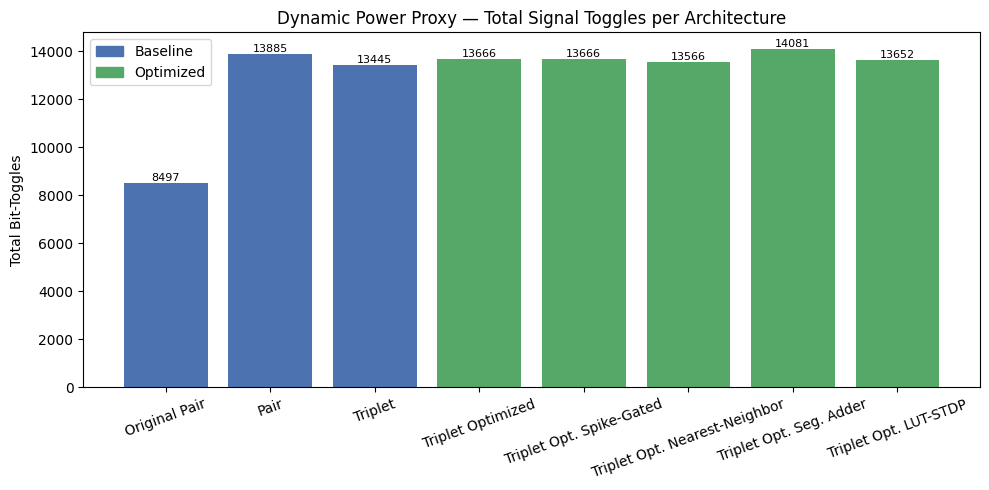

In [18]:
# Plot 1: Total toggle bar chart
if not df_power.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ["#4C72B0" if g == "baseline" else "#55A868" for g in df_power["Group"]]
    bars = ax.bar(df_power["Design"], df_power["Total Toggles"], color=colors)
    ax.set_ylabel("Total Bit-Toggles")
    ax.set_title("Dynamic Power Proxy — Total Signal Toggles per Architecture")
    ax.bar_label(bars, fmt="%d", fontsize=8)
    ax.tick_params(axis="x", rotation=20)

    # Legend
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color="#4C72B0", label="Baseline"),
                       Patch(color="#55A868", label="Optimized")])
    plt.tight_layout()
    plt.show()

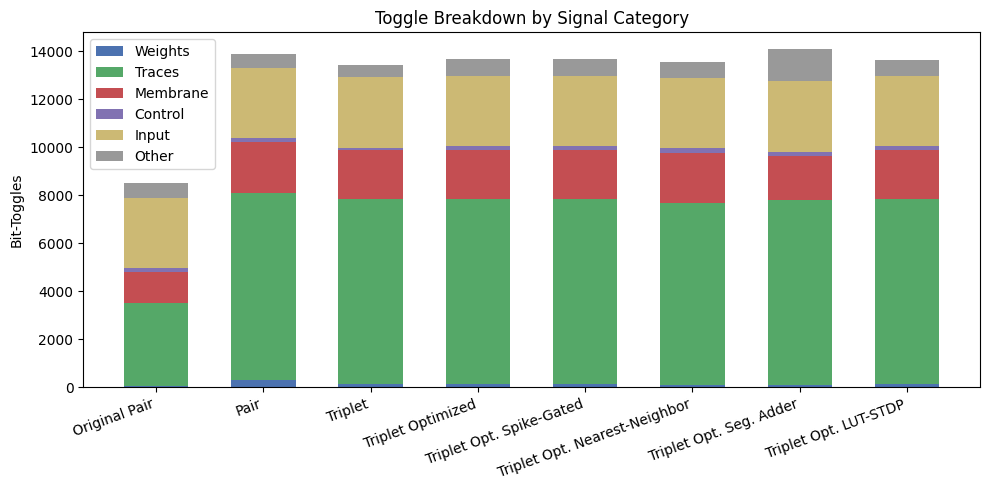

In [19]:
# Plot 2: Stacked bar by signal category
if not df_power.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(df_power))
    width = 0.6
    bottom = np.zeros(len(df_power))

    for cat in CAT_ORDER:
        col = f"{cat.title()} Toggles"
        if col in df_power.columns:
            vals = df_power[col].values.astype(float)
            ax.bar(x, vals, width, bottom=bottom, label=cat.title(), color=CAT_COLORS[cat])
            bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(df_power["Design"], rotation=20, ha="right")
    ax.set_ylabel("Bit-Toggles")
    ax.set_title("Toggle Breakdown by Signal Category")
    ax.legend()
    plt.tight_layout()
    plt.show()

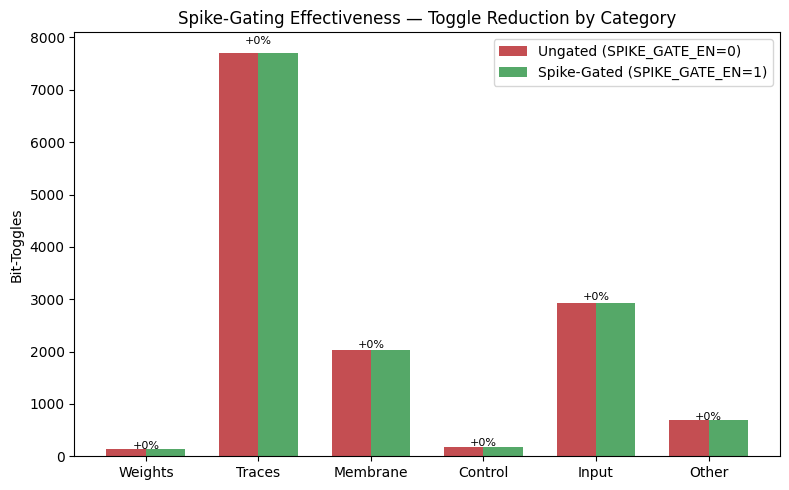

Total toggles — Ungated: 13,666  Gated: 13,666  Reduction: +0.0%


In [20]:
# Plot 3: Spike-gating effectiveness — ungated vs gated side-by-side
gated_key = "triplet_optimized_spike_gated"
ungated_key = "triplet_optimized"

if gated_key in results and ungated_key in results:
    fig, ax = plt.subplots(figsize=(8, 5))

    cats_ungated = results[ungated_key]["categories"]
    cats_gated = results[gated_key]["categories"]

    x = np.arange(len(CAT_ORDER))
    width = 0.35

    vals_ungated = [cats_ungated.get(c, 0) for c in CAT_ORDER]
    vals_gated = [cats_gated.get(c, 0) for c in CAT_ORDER]

    bars1 = ax.bar(x - width/2, vals_ungated, width, label="Ungated (SPIKE_GATE_EN=0)", color="#C44E52")
    bars2 = ax.bar(x + width/2, vals_gated, width, label="Spike-Gated (SPIKE_GATE_EN=1)", color="#55A868")

    ax.set_xticks(x)
    ax.set_xticklabels([c.title() for c in CAT_ORDER])
    ax.set_ylabel("Bit-Toggles")
    ax.set_title("Spike-Gating Effectiveness — Toggle Reduction by Category")
    ax.legend()

    # Annotate percentage reduction
    for i, (u, g) in enumerate(zip(vals_ungated, vals_gated)):
        if u > 0:
            pct = (g - u) / u * 100
            ax.text(i, max(u, g) * 1.02, f"{pct:+.0f}%", ha="center", fontsize=8)

    plt.tight_layout()
    plt.show()

    # Print summary
    total_u = sum(vals_ungated)
    total_g = sum(vals_gated)
    print(f"Total toggles — Ungated: {total_u:,}  Gated: {total_g:,}  Reduction: {(total_g-total_u)/total_u*100:+.1f}%")
else:
    print("Spike-gating comparison requires both triplet_optimized and triplet_optimized_spike_gated results.")

## Active vs Idle Cycles

Count training cycles where weight or trace signals actually toggle (STDP active)
vs cycles with no learning activity (idle). Spike-gating should reduce toggles on idle cycles.

Active vs Idle Cycles (STDP activity):


,Design,Group,Active Cycles,Idle Cycles,Total Cycles,Active Ratio
0,Original Pair,baseline,138,277,415,33.3
1,Pair,baseline,165,250,415,39.8
2,Triplet,baseline,165,250,415,39.8
3,Triplet Optimized,optimized,165,250,415,39.8
4,Triplet Opt. Spike-Gated,optimized,165,250,415,39.8
5,Triplet Opt. Nearest-Neighbor,optimized,156,259,415,37.6
6,Triplet Opt. Seg. Adder,optimized,165,250,415,39.8
7,Triplet Opt. LUT-STDP,optimized,165,250,415,39.8


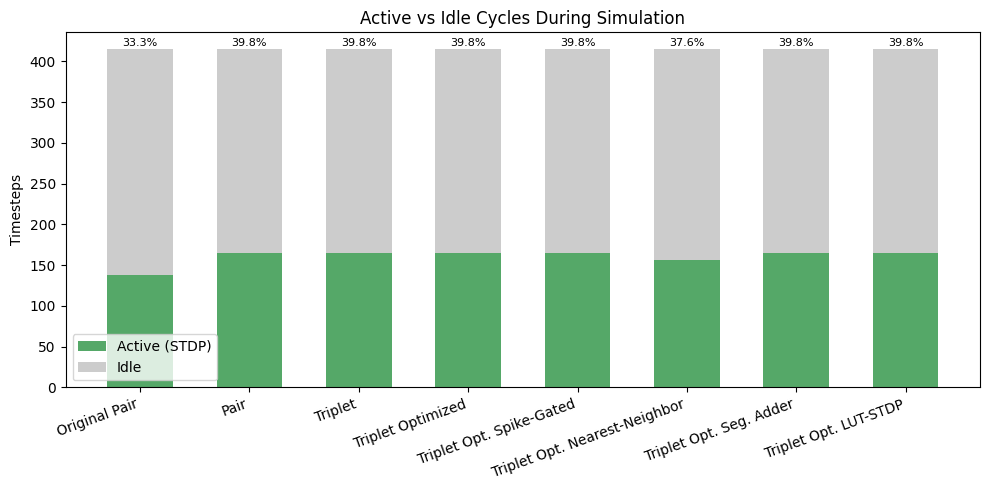

In [21]:
def compute_active_idle(timeline):
    """Count timesteps where weight/trace signals change vs not."""
    active = 0
    idle = 0
    for ts, changed_signals in timeline:
        has_stdp_activity = any(
            categorize_signal(s) in ("weights", "traces")
            for s in changed_signals
        )
        if has_stdp_activity:
            active += 1
        else:
            idle += 1
    return active, idle


activity_rows = []
for key, design in DESIGNS.items():
    if key not in results:
        continue
    active, idle = compute_active_idle(results[key]["timeline"])
    total = active + idle
    activity_rows.append({
        "Design": design["label"],
        "Group": design["group"],
        "Active Cycles": active,
        "Idle Cycles": idle,
        "Total Cycles": total,
        "Active Ratio": round(active / max(total, 1) * 100, 1),
    })

df_activity = pd.DataFrame(activity_rows)
print("Active vs Idle Cycles (STDP activity):")
display(df_activity)

# Plot: Stacked bar of active vs idle
if not df_activity.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(df_activity))
    width = 0.6
    ax.bar(x, df_activity["Active Cycles"], width, label="Active (STDP)", color="#55A868")
    ax.bar(x, df_activity["Idle Cycles"], width, bottom=df_activity["Active Cycles"],
           label="Idle", color="#CCCCCC")
    ax.set_xticks(x)
    ax.set_xticklabels(df_activity["Design"], rotation=20, ha="right")
    ax.set_ylabel("Timesteps")
    ax.set_title("Active vs Idle Cycles During Simulation")
    ax.legend()

    # Annotate active ratio
    for i, row in df_activity.iterrows():
        ax.text(i, row["Total Cycles"] * 1.01, f"{row['Active Ratio']}%",
                ha="center", fontsize=8)

    plt.tight_layout()
    plt.show()

## Training Convergence Speed

Track cumulative weight toggles over simulation time.
Shows when learning stabilizes and whether optimizations affect convergence.

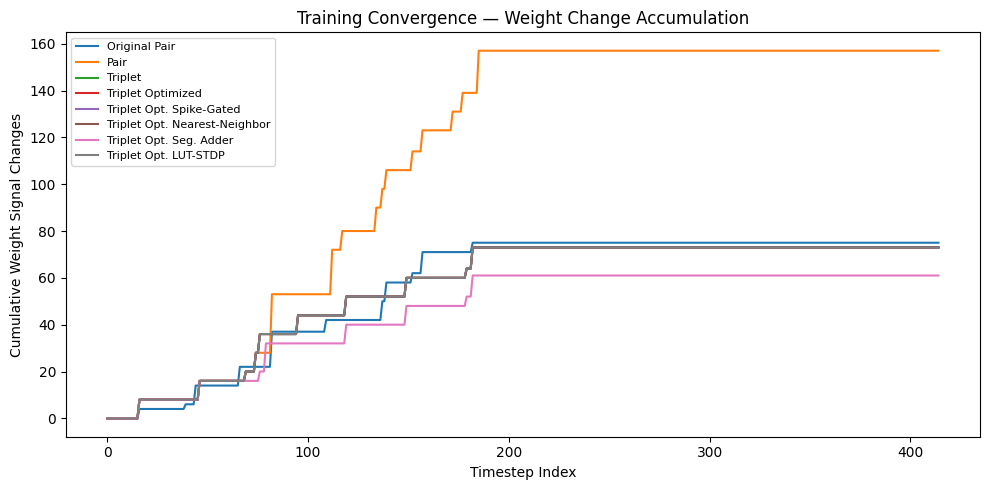

Convergence metrics:


,Design,Total Weight Changes,Last Weight Change (timestep)
0,Original Pair,75,182
1,Pair,157,185
2,Triplet,73,182
3,Triplet Optimized,73,182
4,Triplet Opt. Spike-Gated,73,182
5,Triplet Opt. Nearest-Neighbor,73,182
6,Triplet Opt. Seg. Adder,61,182
7,Triplet Opt. LUT-STDP,73,182


In [22]:
def compute_weight_convergence(timeline):
    """Compute cumulative weight toggles over time.

    Returns list of (timestep_index, cumulative_weight_toggles).
    """
    cumulative = []
    total = 0
    for i, (ts, changed_signals) in enumerate(timeline):
        weight_changes = sum(1 for s in changed_signals if s.startswith(("w1[", "w2[")))
        total += weight_changes
        cumulative.append((i, total))
    return cumulative


def find_last_weight_change(timeline):
    """Find the index of the last timestep with a weight change."""
    last = 0
    for i, (ts, changed_signals) in enumerate(timeline):
        if any(s.startswith(("w1[", "w2[")) for s in changed_signals):
            last = i
    return last


# Plot: Convergence curves
fig, ax = plt.subplots(figsize=(10, 5))

convergence_rows = []
for key, design in DESIGNS.items():
    if key not in results:
        continue
    conv = compute_weight_convergence(results[key]["timeline"])
    last_change = find_last_weight_change(results[key]["timeline"])

    if conv:
        xs, ys = zip(*conv)
        ax.plot(xs, ys, label=design["label"], linewidth=1.5)

    convergence_rows.append({
        "Design": design["label"],
        "Total Weight Changes": conv[-1][1] if conv else 0,
        "Last Weight Change (timestep)": last_change,
    })

ax.set_xlabel("Timestep Index")
ax.set_ylabel("Cumulative Weight Signal Changes")
ax.set_title("Training Convergence — Weight Change Accumulation")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

df_convergence = pd.DataFrame(convergence_rows)
print("Convergence metrics:")
display(df_convergence)

## Inference Spike Latency

During test phases, find when each output neuron first fires.
Earlier spike = faster classification decision.

Inference Spike Latency:


,Design,First N1 Spike (timestep),First N2 Spike (timestep),N1 Spike Events,N2 Spike Events
0,Original Pair,14,149,33,15
1,Pair,14,149,51,6
2,Triplet,14,117,21,18
3,Triplet Optimized,14,117,21,18
4,Triplet Opt. Spike-Gated,14,117,21,18
5,Triplet Opt. Nearest-Neighbor,14,117,24,18
6,Triplet Opt. Seg. Adder,14,117,18,18
7,Triplet Opt. LUT-STDP,14,117,21,18


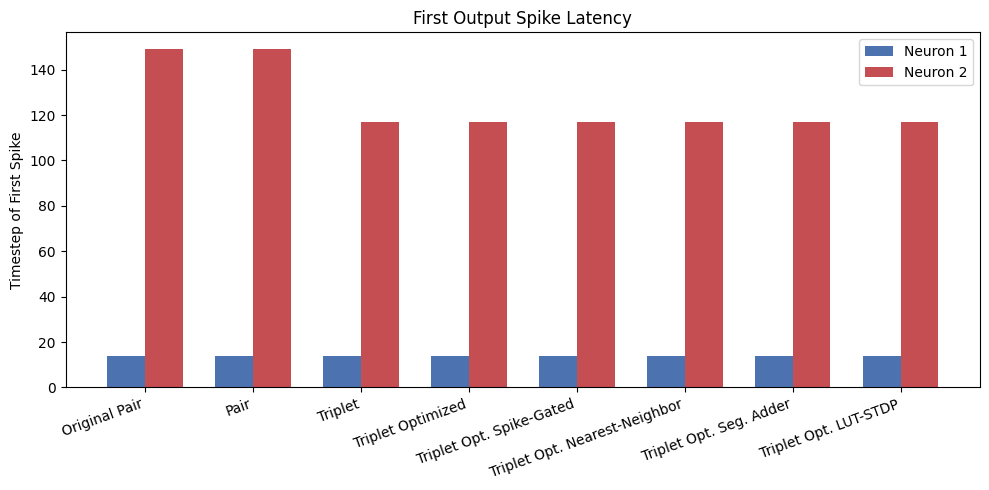

In [23]:
def find_spike_latency(timeline, spike_signal="spike1_now"):
    """Find the first timestep index where a spike signal appears in changes.

    Returns (first_spike_index, total_spikes) or (None, 0) if no spike.
    """
    first = None
    count = 0
    for i, (ts, changed_signals) in enumerate(timeline):
        # spike signals appear when they transition — check both names
        if spike_signal in changed_signals or spike_signal.replace("_now", "") in changed_signals:
            if first is None:
                first = i
            count += 1
    return first, count


# The VCD covers the full simulation (Train '0', Train '1', Test '0', Test '1').
# Each phase is ~40 timesteps + reset. We'll report overall first-spike index.
# For a more precise per-phase breakdown, we'd need phase markers in the VCD.

latency_rows = []
for key, design in DESIGNS.items():
    if key not in results:
        continue

    first_s1, count_s1 = find_spike_latency(results[key]["timeline"], "spike1_now")
    first_s2, count_s2 = find_spike_latency(results[key]["timeline"], "spike2_now")

    # Also check "spike1" / "spike2" names (shared var IDs with testbench)
    if first_s1 is None:
        first_s1, count_s1 = find_spike_latency(results[key]["timeline"], "spike1")
    if first_s2 is None:
        first_s2, count_s2 = find_spike_latency(results[key]["timeline"], "spike2")

    latency_rows.append({
        "Design": design["label"],
        "First N1 Spike (timestep)": first_s1 if first_s1 is not None else "never",
        "First N2 Spike (timestep)": first_s2 if first_s2 is not None else "never",
        "N1 Spike Events": count_s1,
        "N2 Spike Events": count_s2,
    })

df_latency = pd.DataFrame(latency_rows)
print("Inference Spike Latency:")
display(df_latency)

# Plot: Grouped bar of first spike timestep
if not df_latency.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(df_latency))
    width = 0.35

    n1_vals = [v if isinstance(v, (int, float)) else 0 for v in df_latency["First N1 Spike (timestep)"]]
    n2_vals = [v if isinstance(v, (int, float)) else 0 for v in df_latency["First N2 Spike (timestep)"]]

    ax.bar(x - width/2, n1_vals, width, label="Neuron 1", color="#4C72B0")
    ax.bar(x + width/2, n2_vals, width, label="Neuron 2", color="#C44E52")

    ax.set_xticks(x)
    ax.set_xticklabels(df_latency["Design"], rotation=20, ha="right")
    ax.set_ylabel("Timestep of First Spike")
    ax.set_title("First Output Spike Latency")
    ax.legend()
    plt.tight_layout()
    plt.show()

## Summary Table & Export

In [24]:
# Build combined summary
summary_rows = []
for key, design in DESIGNS.items():
    if key not in results:
        continue

    cats = results[key]["categories"]
    total_toggles = sum(results[key]["toggles"].values())
    active, idle = compute_active_idle(results[key]["timeline"])
    last_w = find_last_weight_change(results[key]["timeline"])
    first_s1, _ = find_spike_latency(results[key]["timeline"], "spike1_now")
    first_s2, _ = find_spike_latency(results[key]["timeline"], "spike2_now")
    if first_s1 is None:
        first_s1, _ = find_spike_latency(results[key]["timeline"], "spike1")
    if first_s2 is None:
        first_s2, _ = find_spike_latency(results[key]["timeline"], "spike2")

    delta = ""
    if key != BASELINE_KEY:
        delta = f"{(total_toggles - baseline_total) / baseline_total * 100:+.1f}%"
    else:
        delta = "baseline"

    summary_rows.append({
        "Design": design["label"],
        "Group": design["group"],
        "Total Toggles": total_toggles,
        "\u0394 Toggles": delta,
        "Weight Toggles": cats.get("weights", 0),
        "Active Cycles": active,
        "Active %": round(active / max(active + idle, 1) * 100, 1),
        "Last Weight Change": last_w,
        "1st Spike N1": first_s1 if first_s1 is not None else "—",
        "1st Spike N2": first_s2 if first_s2 is not None else "—",
    })

df_summary = pd.DataFrame(summary_rows)
print("Combined Dynamic Analysis Summary:")
display(df_summary)

# Export
# csv_path = os.path.join(PPA_ROOT, "dynamic_analysis_results.csv")
# df_summary.to_csv(csv_path, index=False)
# print(f"\nSaved: {csv_path}")

Combined Dynamic Analysis Summary:


,Design,Group,Total Toggles,Δ Toggles,Weight Toggles,Active Cycles,Active %,Last Weight Change,1st Spike N1,1st Spike N2
0,Original Pair,baseline,8497,-36.8%,79,138,33.3,182,14,149
1,Pair,baseline,13885,+3.3%,294,165,39.8,185,14,149
2,Triplet,baseline,13445,baseline,132,165,39.8,182,14,117
3,Triplet Optimized,optimized,13666,+1.6%,132,165,39.8,182,14,117
4,Triplet Opt. Spike-Gated,optimized,13666,+1.6%,132,165,39.8,182,14,117
5,Triplet Opt. Nearest-Neighbor,optimized,13566,+0.9%,108,156,37.6,182,14,117
6,Triplet Opt. Seg. Adder,optimized,14081,+4.7%,99,165,39.8,182,14,117
7,Triplet Opt. LUT-STDP,optimized,13652,+1.5%,132,165,39.8,182,14,117
